# Performing iGUESSMD simulations

The aim of this tutorial is to demonstrate how to use the `OMMiGUESSMDSimulation` class to perform iGUESSMD simulations on a reaction path defined from an iMD-XR simulation, refined using the `PathSmoother` class (see the ["PathSmoother tutorial"](https://github.com/IRL2/nanover-server-py/tree/main/tutorials/5.%20iGUESSMD/PathSmoother.ipynb) for details).

In this tutorial we will investigate the helix-to-coil transition of deca-alanine using iGUESSMD. To do so, we use the following pre-prepared files:
- A NanoVer OpenMM XML input file defining the deca-alanine system (with the nitrogen atom of the first residue constrained (mass = 0))
- A refined reaction path, created using the `PathSmoother` class, defining the transition in simulation space.

This tutorial demonstrates the protocol for performing iGUESSMD simulations:
- Create an iGUESSMD simulation object
- Equilibrate the system with the initial restraint of the reaction path
- Generate starting structures
- Perform iGUESSMD simulations for each of the starting structures and saviing the results

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from openmm.app import StateDataReporter

from nanover.iguessmd.openmm import OMMiGUESSMDSimulation
from nanover.iguessmd.pathsmoothing import load_iguessmd_path_data

ps_outfile_path = "../systems/iguessmd/inputs/deca-alanine_refined_iguessmd_path.npy"
omm_xml_infile_path = "../systems/openmm/deca-alanine_constrained.xml"

## Create and equilibrate the iGUESSMD simulation

We will use the `OMMiGUESSMDSimulation` class to perform the iGUESSMD simulation. This class contains all of the methods required to perform iGUESSMD simulations with OpenMM.

As with the NanoVer `OpenMMSimulation` class, the `OMMiGUESSMDSimulation` can be created in two ways:
- from an OpenMM simulations, using the `.from_simulation(...)` function
- from a NanoVer OpenMM XML file in which the simulation is defined

To define the simulation, we will need to pass additional information about the specific reaction path of interest, including the path itself and the indices of the atoms to which the force was applied during the iMD-XR simulation. This information is available in the `PathSmoother` output file. In this case, the force is applied to the nitrogen atom of the final residue, and the reaction path is defined by the refined path taken by this atom relative to the position of the constrained nitrogen atom during the iMD-XR simulation.

We also need to pass the simulation the force constant to use for the iGUESSMD restraint. This can either be a single float (for a spherically symmetric harmonic potential) or a NumPy array containing two floats, which define the force constants of the components of the harmonic potential parallel and perpendicular to the reaction path, respectively (i.e. `np.array([k_par, k_perp])`). For this example, we will use a spherically symmetric iGUESSMD restraint with strength $3011\,\mathrm{kJ}\,\mathrm{mol}^{-1}\,\mathrm{nm}^{-2}$, corresponding to approximately $500\,\mathrm{pN}\,\mathrm{Å}^{-1}$.

In [2]:
# Load data from PathSmoother
iguessmd_path_data = load_iguessmd_path_data(ps_outfile_path)

# Define force constant in units kJ mol-1 nm-2
iguessmd_fc = 3011.0

# Create the iGUESSMD simulation
iguessmd_sim = OMMiGUESSMDSimulation.from_xml_path(path=omm_xml_infile_path,
                                                   iguessmd_atom_indices=iguessmd_path_data['iguessmd_atom_indices'],
                                                   iguessmd_path=iguessmd_path_data['iguessmd_path'],
                                                   iguessmd_force_constant=iguessmd_fc,
                                                   name="OpenMM iGUESSMD Simulation")

Once the system has been created, we want to equilibrate the system with the iGUESSMD at its initial position, such that we sample our initial coordinates (positions and velocities) for the iGUESSMD simulations from an equilibrium ensemble with this perturbation. To do so we simply define the number of equilibration steps to perform the simulation for and pass it to the `run_equilibration_with_initial_restraint` method.

To check that our simulation equilibrates properly, we can add an OpenMM `StateDataReporter` to our simulation to record the temperature and potential energy of the simulation.

In [3]:
# Run simulation for 1 nanosecond (2 fs timestep)
n_steps_eq = 500000

# [OPTIONAL] Add reporter to the simulation
reporter_filepath = "./iguessmd_equilibration.txt"
reporter = StateDataReporter(file=reporter_filepath, reportInterval=100, time=True, potentialEnergy=True, temperature=True)
iguessmd_sim.simulation.reporters.append(reporter)

iguessmd_sim.run_equilibration_with_initial_restraint(n_steps=n_steps_eq)

# [OPTIONAL] Clear reporter
iguessmd_sim.simulation.reporters.clear()

We can check the geometry of the simulation (which we want to remain helical at the initial geometry) using MDAnalysis and NGLView

In [4]:
import MDAnalysis as mda
import nglview as ngl

u = mda.Universe(iguessmd_sim.simulation)

view = ngl.show_mdanalysis(u)
view

/opt/homebrew/Caskroom/miniforge/base/envs/nanover-dev/lib/python3.13/site-packages/MDAnalysis/converters/OpenMM.py:116: UserWarning: Reader has no dt information, set to 1.0 ps
  self.convert_time_from_native(self.ts.dt)


NGLWidget()

If the structure above is helical, we can proceed. We'll close the window above to reduce clutter.

In [5]:
view.close()

If a reporter was added, we can then check the progression of the quantities saved by the StateDataReporter across the equilibration.

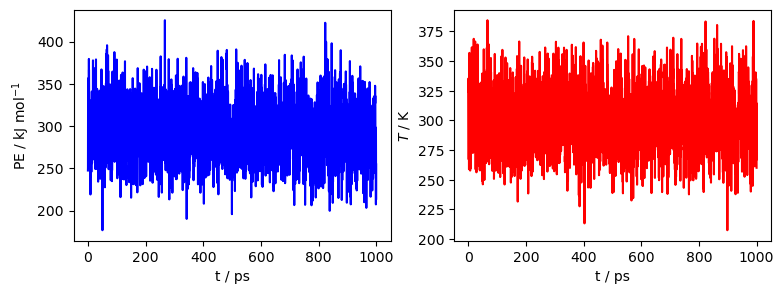

In [8]:
import pandas as pd

df = pd.read_csv(reporter_filepath)

# Create plot
fig, axs = plt.subplots(ncols=2, figsize=(9, 3))

# Plot PE
axs[0].plot(df["#\"Time (ps)\""] - df["#\"Time (ps)\""][0], df["Potential Energy (kJ/mole)"], color="blue")
axs[0].set_xlabel("t / ps")
axs[0].set_ylabel(r"PE / kJ mol$^{-1}$")

# Plot temperature
axs[1].plot(df["#\"Time (ps)\""] - df["#\"Time (ps)\""][0], df["Temperature (K)"], color='red')
axs[1].set_xlabel("t / ps")
axs[1].set_xlabel("t / ps")
axs[1].set_ylabel(r"$T$ / K")

# Show equilibration plots
plt.show()

## Generating starting structures

Now that we have an equilibrated simulation, we can run a simulation to sample some initial coordinates to use in our iGUESSMD simulations. To do this, we specify the number of sets of initial coordinates we want to sample, and the simulation time window during which we want to sample them (in picoseconds).

These initial coordinates will be saved to NanoVer OpenMM XML files, such that we can easily load them into new instances of the `OMMiGUESSMDSimulation` class and perform the iGUESSMD simulations separately. Doing so allows us to perform these simulations in parallel. We therefore need to specify the output file directory (we'll create one locally here), as well as file name prefix.

In [11]:
# Create directory for generated starting structures
initial_coord_dir = "./initial_coords"
os.makedirs(initial_coord_dir, exist_ok=True)

# Generate 10 structures during 1 ns simulation,
# optionally saving the iGUESSMD force to the files (default False)
iguessmd_sim.generate_starting_structures(
    interval_ps=1000,
    n_structures=10,
    output_directory=initial_coord_dir,
    filename_prefix="deca-alanine_initial_coords",
    save_iguessmd_force=True,
)

Generating 10 structures in 1000 ps simulation...
Structures will be saved to ./initial_coords

Structure generation complete: 10 structures generated.


That's it! We now have our 10 starting structures generated. Let's do another check to make sure our system is still in a helical geometry:

In [12]:
u = mda.Universe(iguessmd_sim.simulation)

view = ngl.show_mdanalysis(u)
view

/opt/homebrew/Caskroom/miniforge/base/envs/nanover-dev/lib/python3.13/site-packages/MDAnalysis/converters/OpenMM.py:116: UserWarning: Reader has no dt information, set to 1.0 ps
  self.convert_time_from_native(self.ts.dt)


NGLWidget()

If it is, then great! We can move on to running iGUESSMD simulations on the starting coordinates we've generated. Again, let's close the structure viewer to keep things clean.

In [13]:
view.close()

## Running iGUESSMD simulations